# Dispersion · Polynomial Chirp · Linear Algebra · 3D TD-GSA · Digital Twin

**Stack:** SymPy (symbolic) → NumPy (vectorized) → Torch (batch) → Matplotlib

§1 Polynomial chirp — β-expansion, group delay, GDD / TOD / FOD (4th order)  
§2 Linear algebra of dispersion — transfer matrix, Jones calculus, eigenmodes  
§3 Differential equations — NLS, split-step Fourier method  
§4 3D TD-GSA — 3D time-domain Gerchberg-Saxton phase retrieval  
§5 Digital twin — `PhotonicLink` class encapsulating live fiber state  
§6 Torch batch — (β₂, L, T₀) parameter grid, dispersion map

In [15]:
import sympy as sp
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from dataclasses import dataclass, field
from typing import Optional, Dict, List
from IPython.display import display, Math
import warnings; warnings.filterwarnings('ignore')

sp.init_printing(use_latex='mathjax')
plt.rcParams.update({'font.size': 11, 'figure.dpi': 110})
torch.set_default_dtype(torch.float64)
print('ready')

ready


---
# §1 — Polynomial Chirp: β-Expansion to 4th Order

**Taylor expansion of propagation constant** $\\beta(\\omega)$ about carrier $\\omega_0$:

$$\\beta(\\omega) = \\beta_0 + \\beta_1(\\omega-\\omega_0) + \\frac{\\beta_2}{2}(\\omega-\\omega_0)^2 + \\frac{\\beta_3}{6}(\\omega-\\omega_0)^3 + \\frac{\\beta_4}{24}(\\omega-\\omega_0)^4 + \\cdots$$

| Term | Name | Units | Physical meaning |
|------|------|-------|------------------|
| $\\beta_1$ | inverse group velocity | s/m | pulse travel time |
| $\\beta_2$ | GVD / chirp | s²/m | pulse broadening, anomalous<0/normal>0 |
| $\\beta_3$ | TOD | s³/m | asymmetric broadening |
| $\\beta_4$ | FOD | s⁴/m | symmetric higher-order |

**Instantaneous chirp:** $\\delta\\omega(t) = -\\frac{d\\phi}{dt}$ — frequency swept by the pulse.

In [16]:
omega, omega0, z, t_var = sp.symbols('omega omega_0 z t', real=True)
b0, b1, b2, b3, b4 = sp.symbols('beta_0 beta_1 beta_2 beta_3 beta_4', real=True)
T0, A0 = sp.symbols('T_0 A_0', positive=True)

# ── β(ω) polynomial ──────────────────────────────────────────────
dw = omega - omega0
beta_poly = (b0 + b1*dw + b2*dw**2/2 + b3*dw**3/6 + b4*dw**4/24)

display(Math(r'\beta(\omega) = ' + sp.latex(beta_poly)))

# ── Group delay: τ(ω) = dβ/dω * z ───────────────────────────────
group_delay = sp.diff(beta_poly, omega) * z
group_delay_s = sp.simplify(group_delay)
print('\nGroup delay τ(ω) = z · dβ/dω:')
display(Math(r'\tau(\omega) = z\cdot\frac{d\beta}{d\omega} = ' + sp.latex(group_delay_s)))

# ── GVD, TOD, FOD as derivatives ─────────────────────────────────
print('\nDerivatives of β (dispersion coefficients):')
for n_order in range(1, 5):              # loop over derivative orders
    dn = sp.diff(beta_poly, omega, n_order)
    dn_s = sp.simplify(dn.subs(dw, 0))
    names = {1:'β₁ (group velocity⁻¹)', 2:'β₂ (GVD)',
             3:'β₃ (TOD)', 4:'β₄ (FOD)'}
    display(Math(r'\frac{d^' + str(n_order) + r'\beta}{d\omega^' + str(n_order) +
                 r'}\bigg|_{\omega_0} = ' + sp.latex(dn_s) +
                 r'\quad \text{(' + names[n_order] + r')}'))

# ── Transfer function H(ω) = exp(i·β(ω)·z) ──────────────────────
print('\nFiber transfer function:')
H_fiber = sp.exp(sp.I * beta_poly * z)
display(Math(r'H(\omega,z) = e^{i\beta(\omega)z} = ' + sp.latex(H_fiber)))

# ── Phase expansion of a chirped Gaussian pulse ───────────────────
# E(t) = A0 * exp(-t²/2T0²) * exp(i*C*t²/2T0²)
C_chirp = sp.Symbol('C', real=True)   # chirp parameter
phi_t   = -C_chirp * t_var**2 / (2 * T0**2)   # quadratic phase
inst_freq = -sp.diff(phi_t, t_var)
print('\nInstantaneous frequency sweep (linear chirp):')
display(Math(r'\delta\omega(t) = -\frac{d\phi}{dt} = ' + sp.latex(sp.simplify(inst_freq))))

<IPython.core.display.Math object>


Group delay τ(ω) = z · dβ/dω:


<IPython.core.display.Math object>


Derivatives of β (dispersion coefficients):


<IPython.core.display.Math object>

...

<IPython.core.display.Math object>


Fiber transfer function:


<IPython.core.display.Math object>


Instantaneous frequency sweep (linear chirp):


<IPython.core.display.Math object>

Dispersion length L_D = 46.1 m


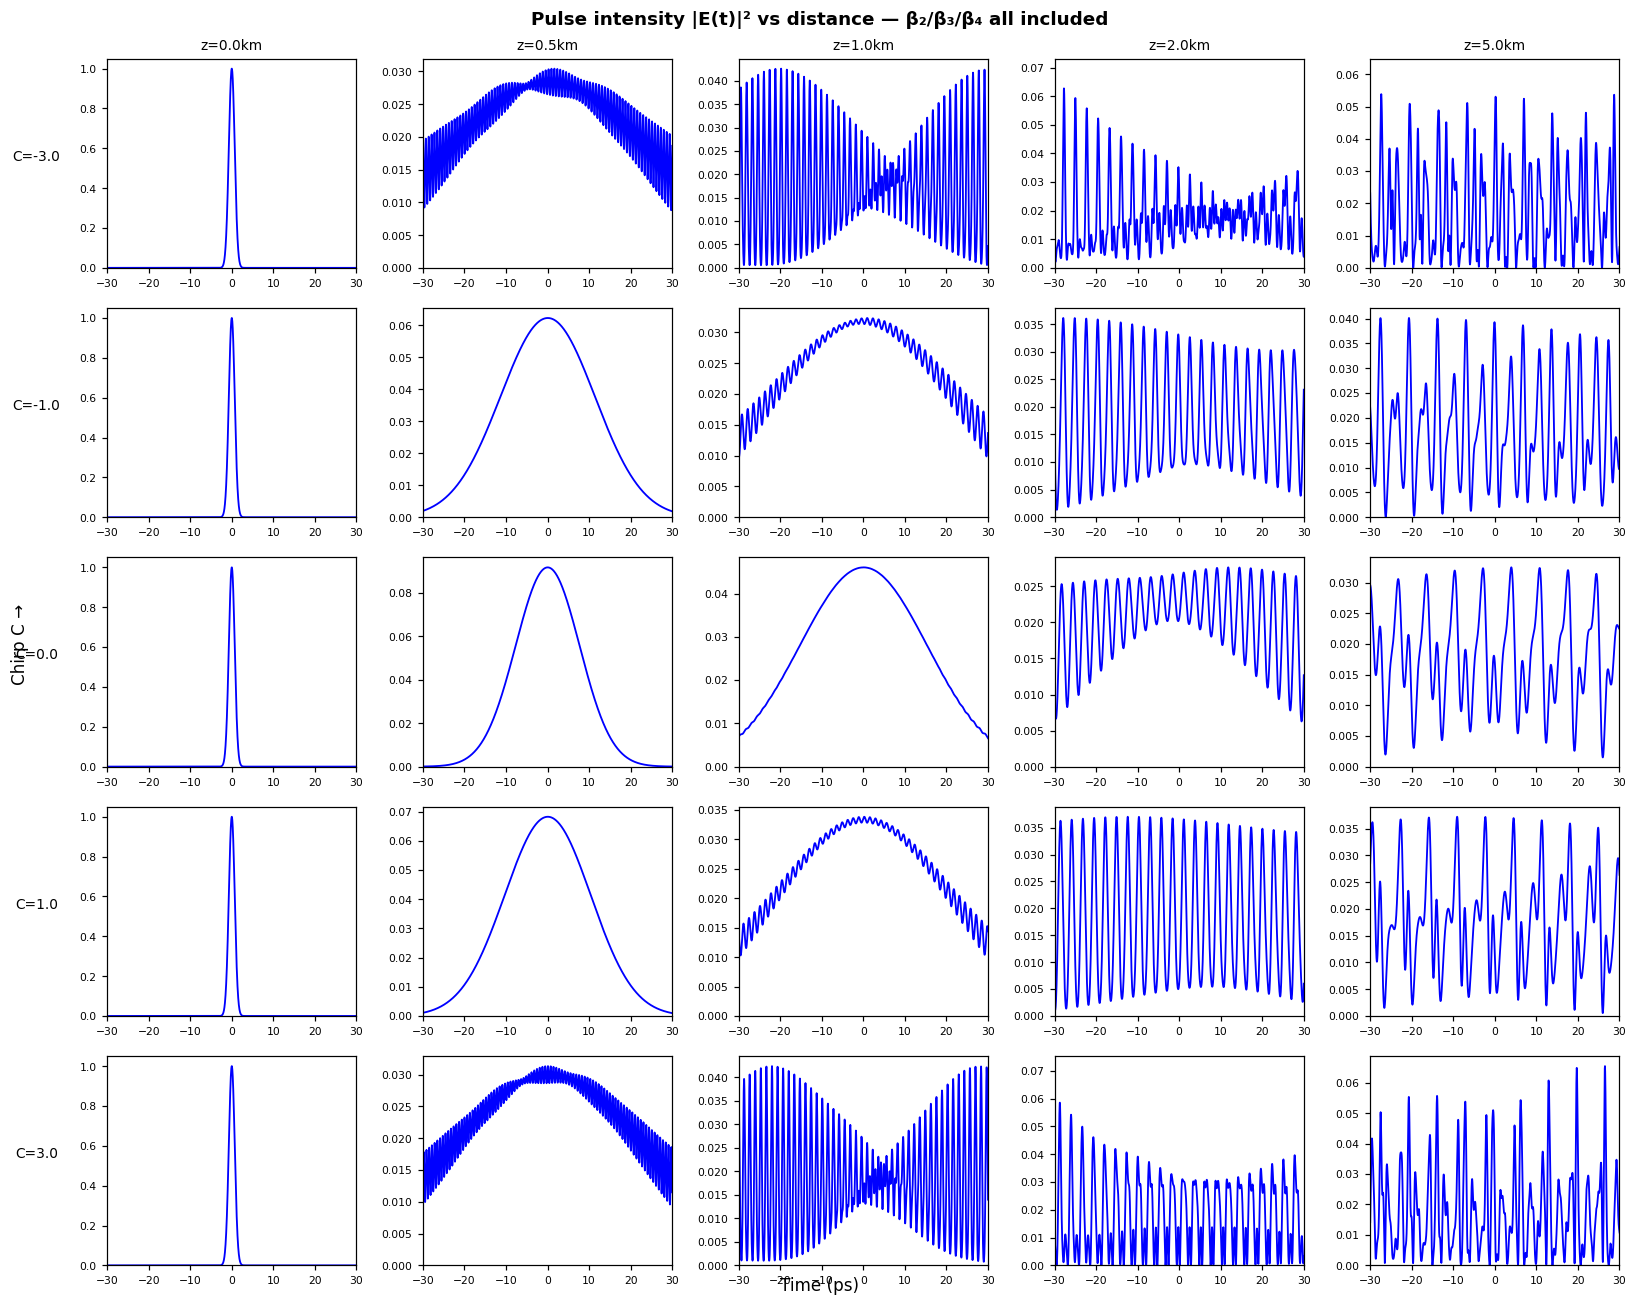

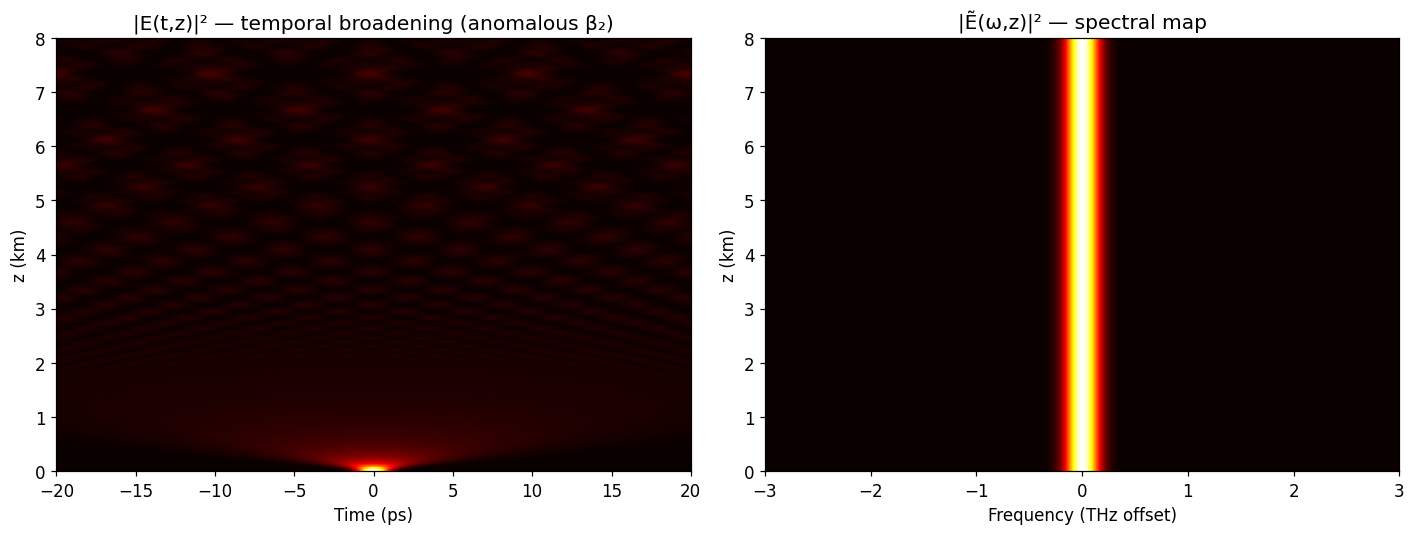

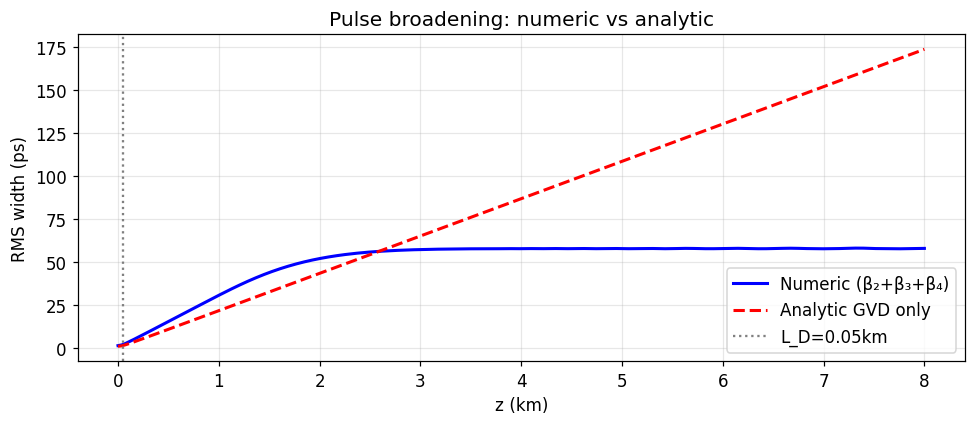

In [17]:
# ── Numerical: pulse propagation with 4-term β expansion ─────────
# Parameters: SMF-28 fiber
c_light  = 3e8        # m/s
lam0     = 1550e-9    # m, carrier wavelength
omega0_v = 2*np.pi*c_light/lam0

# β coefficients (SMF-28 at 1550 nm)
beta2_v  = -21.7e-27  # s²/m   (anomalous, <0)
beta3_v  =  0.12e-39  # s³/m
beta4_v  = -0.5e-55   # s⁴/m

# Pulse parameters
T0_v    = 1e-12       # 1 ps pulse width
N_pts   = 4096
T_window= 100e-12     # 100 ps window
t_arr   = np.linspace(-T_window/2, T_window/2, N_pts)
dt      = t_arr[1] - t_arr[0]
omega_arr = 2*np.pi*np.fft.fftfreq(N_pts, dt)

def gaussian_pulse(t, T0, chirp_C=0.0):
    """Chirped Gaussian: E(t) = exp(-((1+iC)/2)*(t/T0)^2)"""
    return np.exp(-((1 + 1j*chirp_C)/2) * (t/T0)**2)

def propagate_gvd(E_in, omega, z, b2, b3=0, b4=0):
    """Propagate field E(t) through length z using transfer function H(omega)."""
    E_omega = np.fft.fft(E_in)
    phi_disp = (b2/2 * omega**2 + b3/6 * omega**3 + b4/24 * omega**4) * z
    H        = np.exp(1j * phi_disp)
    return np.fft.ifft(E_omega * H)

# ── Loop over chirp parameters ─────────────────────────────────────
chirp_vals = [-3.0, -1.0, 0.0, 1.0, 3.0]
z_vals     = np.array([0, 500, 1000, 2000, 5000])  # meters of fiber
L_D        = T0_v**2 / abs(beta2_v)               # dispersion length
print(f'Dispersion length L_D = {L_D:.1f} m')

fig, axes = plt.subplots(len(chirp_vals), len(z_vals), figsize=(15, 12))
for row, C in enumerate(chirp_vals):              # loop over chirp values
    E0 = gaussian_pulse(t_arr, T0_v, C)
    for col, z_val in enumerate(z_vals):          # loop over distances
        Ez = propagate_gvd(E0, omega_arr, z_val, beta2_v, beta3_v, beta4_v)
        ax = axes[row][col]
        ax.plot(t_arr*1e12, np.abs(Ez)**2, 'b-', lw=1.2)
        ax.set_xlim(-30, 30); ax.set_ylim(bottom=0)
        if row==0: ax.set_title(f'z={z_val/1000:.1f}km', fontsize=9)
        if col==0: ax.set_ylabel(f'C={C}', fontsize=9, rotation=0, labelpad=28)
        ax.tick_params(labelsize=7)

fig.text(0.5, 0.01, 'Time (ps)', ha='center', fontsize=11)
fig.text(0.01, 0.5, 'Chirp C →', va='center', rotation='vertical', fontsize=11)
plt.suptitle('Pulse intensity |E(t)|² vs distance — β₂/β₃/β₄ all included',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

# ── FROG-style trace: |E(t,z)|² as 2D map ─────────────────────────
E0 = gaussian_pulse(t_arr, T0_v, 0.0)
z_grid = np.linspace(0, 8000, 200)
intensity_map = np.zeros((len(z_grid), N_pts))
for iz, zz in enumerate(z_grid):                  # loop over propagation distance
    Ez = propagate_gvd(E0, omega_arr, zz, beta2_v, beta3_v, beta4_v)
    intensity_map[iz] = np.abs(Ez)**2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
# temporal evolution
ax1.imshow(intensity_map, aspect='auto',
           extent=[t_arr[0]*1e12, t_arr[-1]*1e12, z_grid[0]/1000, z_grid[-1]/1000],
           origin='lower', cmap='hot')
ax1.set_xlabel('Time (ps)'); ax1.set_ylabel('z (km)')
ax1.set_title('|E(t,z)|² — temporal broadening (anomalous β₂)')
ax1.set_xlim(-20, 20)

# spectral evolution
spec_map = np.zeros((len(z_grid), N_pts))
for iz, zz in enumerate(z_grid):                  # loop: spectral map
    Ez = propagate_gvd(E0, omega_arr, zz, beta2_v, beta3_v, beta4_v)
    spec_map[iz] = np.abs(np.fft.fftshift(np.fft.fft(Ez)))**2
f_arr = np.fft.fftshift(np.fft.fftfreq(N_pts, dt))
ax2.imshow(spec_map, aspect='auto',
           extent=[f_arr[0]*1e-12, f_arr[-1]*1e-12, z_grid[0]/1000, z_grid[-1]/1000],
           origin='lower', cmap='hot')
ax2.set_xlabel('Frequency (THz offset)'); ax2.set_ylabel('z (km)')
ax2.set_title('|Ẽ(ω,z)|² — spectral map')
ax2.set_xlim(-3, 3)
plt.tight_layout(); plt.show()

# ── Pulse width vs z: all β orders ────────────────────────────────
T_width = []
for iz, zz in enumerate(z_grid):                  # loop
    Ez = propagate_gvd(E0, omega_arr, zz, beta2_v, beta3_v, beta4_v)
    I = np.abs(Ez)**2; I /= I.sum()
    mu = (t_arr * I).sum()
    T_width.append(2*np.sqrt(((t_arr-mu)**2 * I).sum()))

# analytic: Gaussian GVD broadening T(z) = T0*sqrt(1+(z/L_D)^2)
T_analytic = T0_v * np.sqrt(1 + (z_grid/L_D)**2)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(z_grid/1000, np.array(T_width)*1e12, 'b-', lw=2, label='Numeric (β₂+β₃+β₄)')
ax.plot(z_grid/1000, T_analytic*1e12, 'r--', lw=2, label='Analytic GVD only')
ax.axvline(L_D/1000, ls=':', color='gray', label=f'L_D={L_D/1000:.2f}km')
ax.set_xlabel('z (km)'); ax.set_ylabel('RMS width (ps)')
ax.set_title('Pulse broadening: numeric vs analytic'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
# §2 — Linear Algebra of Dispersion: Transfer Matrix, Jones Calculus, Eigenmodes

**Transfer matrix method:** a cascade of optical elements is a product of 2×2 matrices.

$$M_{\\text{total}} = M_N \\cdots M_2 M_1, \\quad \\begin{pmatrix} E_{\\text{out}} \\\\ B_{\\text{out}} \\end{pmatrix} = M_{\\text{total}} \\begin{pmatrix} E_{\\text{in}} \\\\ B_{\\text{in}} \\end{pmatrix}$$

**Jones calculus:** polarization state as 2-vector, each optical element is a 2×2 complex matrix.

Jones matrices:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>


Cascaded Jones matrix (QWP→HWP→PBS):


<IPython.core.display.Math object>

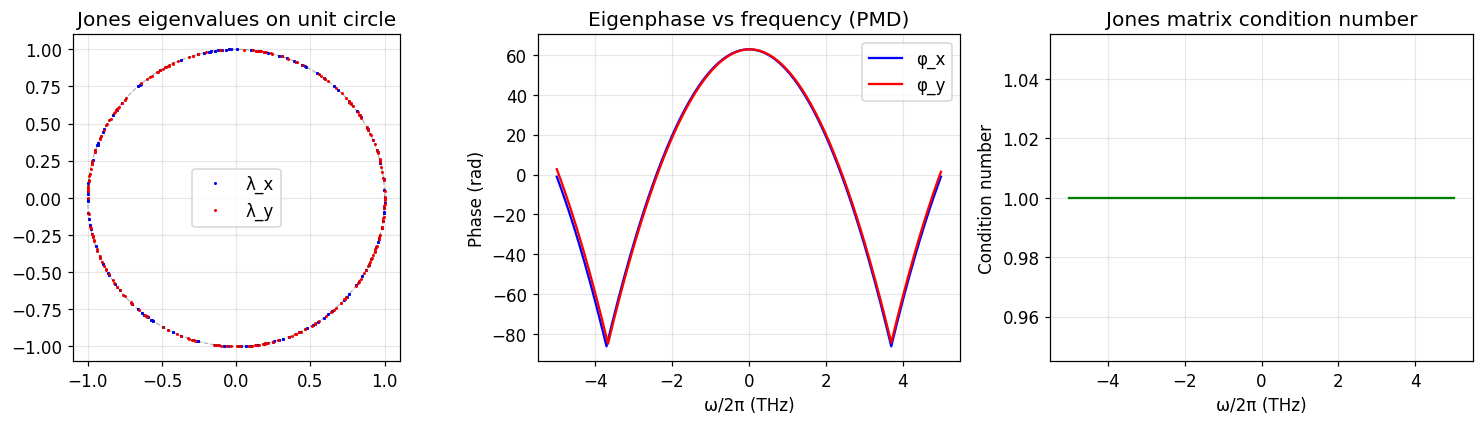

In [18]:
# ── SymPy: transfer matrix for a dispersive fiber segment ─────────
omega_s, z_s = sp.symbols('omega z', real=True, positive=True)
b2_s, b3_s, b4_s = sp.symbols('beta_2 beta_3 beta_4', real=True)

# Phase accumulated by field: φ = β(ω)·z
# Transfer matrix for dispersive medium (scalar, single polarization)
phi_s = (b2_s/2*omega_s**2 + b3_s/6*omega_s**3 + b4_s/24*omega_s**4) * z_s
H_s = sp.exp(sp.I * phi_s)

# ── Jones matrices (symbolic) ─────────────────────────────────────
theta, delta, phi_j = sp.symbols('theta delta phi', real=True)

J_HWP = sp.Matrix([[sp.cos(2*theta), sp.sin(2*theta)],
                    [sp.sin(2*theta),-sp.cos(2*theta)]])  # HWP at angle θ

J_QWP = sp.Matrix([[sp.cos(theta)**2 + sp.I*sp.sin(theta)**2,
                    (1-sp.I)*sp.sin(theta)*sp.cos(theta)],
                   [(1-sp.I)*sp.sin(theta)*sp.cos(theta),
                    sp.sin(theta)**2 + sp.I*sp.cos(theta)**2]])  # QWP

J_PBS = sp.Matrix([[1,0],[0,0]])   # polarizing beam splitter (pass H)

J_rot = sp.Matrix([[sp.cos(theta),-sp.sin(theta)],
                   [sp.sin(theta), sp.cos(theta)]])  # rotation

J_phase = sp.Matrix([[1,0],[0,sp.exp(sp.I*delta)]])  # waveplate phase retarder

print('Jones matrices:')
for name, J in [('HWP', J_HWP),('QWP', J_QWP),('PBS', J_PBS),
                ('Rotation', J_rot),('Phase retarder', J_phase)]:  # loop
    display(Math(r'J_{\text{' + name.replace(' ','~') + r'}} = ' + sp.latex(J)))

# ── Cascade: QWP(45°) → HWP(22.5°) → PBS ─────────────────────────
t45  = sp.pi/4; t225 = sp.pi/8
J_total = J_PBS * J_HWP.subs(theta, t225) * J_QWP.subs(theta, t45)
J_total_s = sp.simplify(J_total)
print('\nCascaded Jones matrix (QWP→HWP→PBS):')
display(Math(r'J_{\text{total}} = ' + sp.latex(J_total_s)))

# ── Eigenmode analysis (numerical): dispersive birefringent fiber ──
n_freqs = 256
omega_num = np.linspace(-5e12, 5e12, n_freqs)   # rad/s offset

# PMD: differential group delay between x,y polarizations
DGD = 0.5e-12   # 0.5 ps differential group delay

eigenvalues_x = []
eigenvalues_y = []
jones_mats    = []

for om in omega_num:            # loop over frequencies: build Jones matrix
    phi_x = beta2_v/2 * om**2 * 1000   # GVD, 1 km
    phi_y = phi_x + DGD * om           # add PMD
    J_fiber = np.array([[np.exp(1j*phi_x), 0],
                         [0,                np.exp(1j*phi_y)]])
    jones_mats.append(J_fiber)
    eigs = np.linalg.eigvals(J_fiber)
    eigenvalues_x.append(eigs[0])
    eigenvalues_y.append(eigs[1])

# ── plot eigenvalue phases on unit circle ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# eigenvalue trajectories on unit circle
axes[0].plot(np.real(eigenvalues_x), np.imag(eigenvalues_x), 'b.', ms=2, label='λ_x')
axes[0].plot(np.real(eigenvalues_y), np.imag(eigenvalues_y), 'r.', ms=2, label='λ_y')
theta_circ = np.linspace(0, 2*np.pi, 200)
axes[0].plot(np.cos(theta_circ), np.sin(theta_circ), 'k--', lw=0.8, alpha=0.3)
axes[0].set_aspect('equal'); axes[0].legend()
axes[0].set_title('Jones eigenvalues on unit circle'); axes[0].grid(True, alpha=0.3)

# phase vs frequency
axes[1].plot(omega_num*1e-12, np.unwrap(np.angle(eigenvalues_x)), 'b-', lw=1.5, label='φ_x')
axes[1].plot(omega_num*1e-12, np.unwrap(np.angle(eigenvalues_y)), 'r-', lw=1.5, label='φ_y')
axes[1].set_xlabel('ω/2π (THz)'); axes[1].set_ylabel('Phase (rad)')
axes[1].set_title('Eigenphase vs frequency (PMD)'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

# condition number of Jones matrix vs frequency
cond_nums = [np.linalg.cond(J) for J in jones_mats]
axes[2].plot(omega_num*1e-12, cond_nums, 'g-', lw=1.5)
axes[2].set_xlabel('ω/2π (THz)'); axes[2].set_ylabel('Condition number')
axes[2].set_title('Jones matrix condition number'); axes[2].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
# §3 — Differential Equations: NLS and Split-Step Fourier

**Nonlinear Schrödinger equation (NLSE):**

$$\\frac{\\partial A}{\\partial z} = -\\frac{i\\beta_2}{2}\\frac{\\partial^2 A}{\\partial t^2} + \\frac{\\beta_3}{6}\\frac{\\partial^3 A}{\\partial t^3} + i\\gamma|A|^2 A - \\frac{\\alpha}{2}A$$

**Split-step Fourier method:**  
$A(z+h,t) = e^{hD}e^{hN}A(z,t)$ where $D = -i\\beta_2\\omega^2/2 + ...$ (linear step in frequency domain),  
$N = i\\gamma|A|^2$ (nonlinear step in time domain).

Linear dispersion operator D̂(ω):


<IPython.core.display.Math object>


Dispersion-compensating fiber D̂_DCF:


<IPython.core.display.Math object>


D + D_DCF (β₃=β₄=0) = 0  ← perfect cancellation
Soliton order N = 0.24


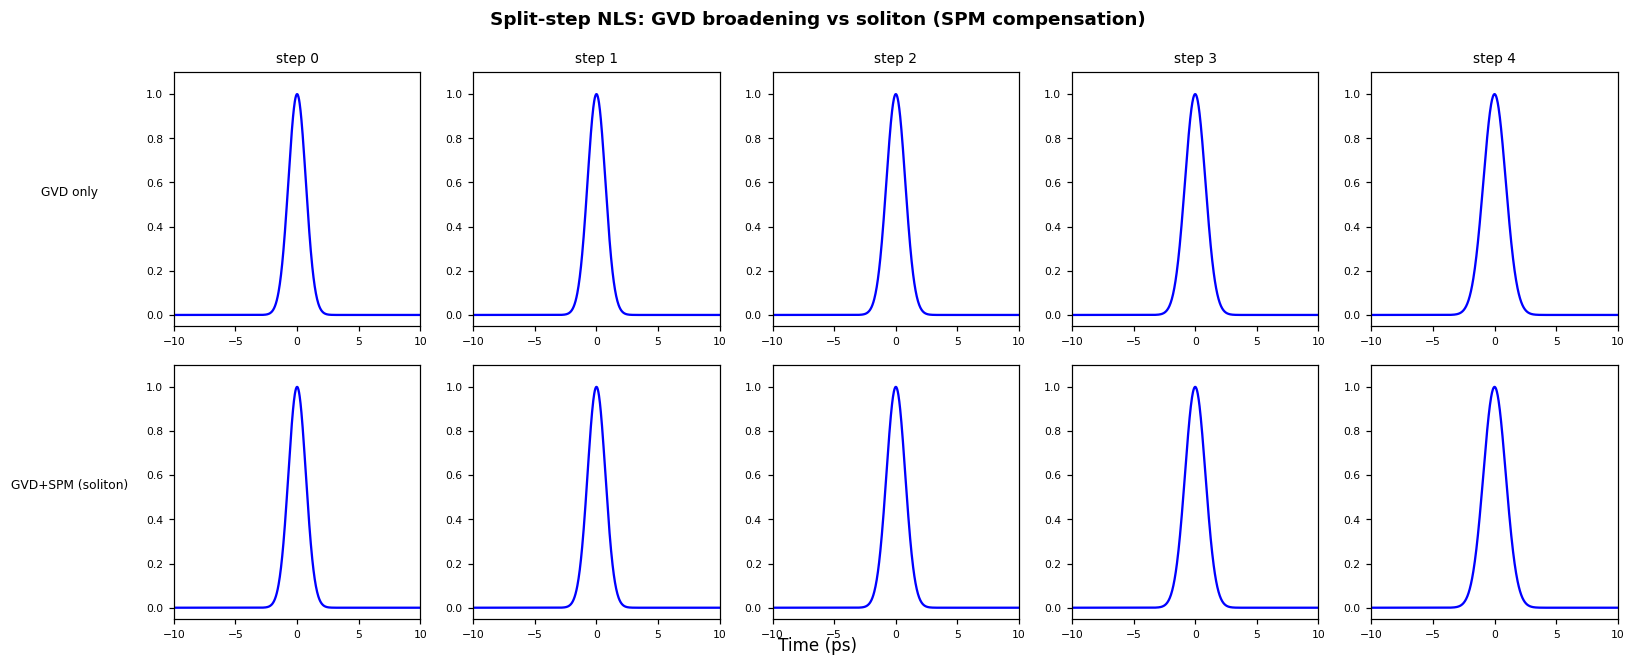

In [19]:
# ── SymPy: derive split-step operators ────────────────────────────
A_sym = sp.Function('A')(z_s, t_var)
gamma_s, alpha_s = sp.symbols('gamma alpha', positive=True)

# Linear operator D (in frequency domain): D̂ Ã = (-iβ₂ω²/2 + β₃ω³/6)Ã
D_hat = -sp.I*b2_s*omega_s**2/2 + b3_s*omega_s**3/6 - b4_s*omega_s**4/24
print('Linear dispersion operator D̂(ω):')
display(Math(r'\hat{D}(\omega) = ' + sp.latex(D_hat)))

# Dispersion-compensating fiber: β₂ flipped
D_hat_DCF = D_hat.subs(b2_s, -b2_s)
print('\nDispersion-compensating fiber D̂_DCF:')
display(Math(r'\hat{D}_{\text{DCF}}(\omega) = ' + sp.latex(D_hat_DCF)))

# Verify: D + D_DCF = 0 for pure GVD case (β3=β4=0)
cancel = sp.simplify((D_hat + D_hat_DCF).subs([(b3_s,0),(b4_s,0)]))
print(f'\nD + D_DCF (β₃=β₄=0) = {cancel}  ← perfect cancellation')

# ── Numerical: split-step Fourier ─────────────────────────────────
def split_step_NLS(E0, t, omega, z_total, dz,
                   b2, b3=0.0, b4=0.0, gamma=0.0, alpha=0.0):
    """
    Split-step Fourier NLSE solver.
    Returns E(t) at z=z_total and list of intermediate snapshots.
    """
    E = E0.copy()
    n_steps = int(z_total / dz)
    # linear phase factor per step
    phi_lin = np.exp(1j * (b2/2*omega**2 + b3/6*omega**3 - b4/24*omega**4) * dz
                     - alpha/2 * dz)
    snapshots = []
    for step in range(n_steps):              # loop: march in z
        # nonlinear half-step
        if gamma != 0:
            E *= np.exp(1j * gamma * np.abs(E)**2 * dz/2)
        # linear full step (in freq domain)
        E_omega = np.fft.fft(E)
        E_omega *= phi_lin
        E = np.fft.ifft(E_omega)
        # nonlinear half-step
        if gamma != 0:
            E *= np.exp(1j * gamma * np.abs(E)**2 * dz/2)
        if step % (n_steps//10) == 0:
            snapshots.append(E.copy())
    return E, snapshots

# ── Compare GVD-only vs GVD+SPM (soliton) ─────────────────────────
E0_clean = gaussian_pulse(t_arr, T0_v, 0.0)

# Soliton condition: N² = γP0 L_D = 1 → γ = 1/(P0*L_D)
P0     = np.max(np.abs(E0_clean)**2)
gamma_v= 1.3e-3   # 1/W/m (standard SMF)
N_sol  = np.sqrt(gamma_v * P0 * L_D)
print(f'Soliton order N = {N_sol:.2f}')

z_prop = 2 * L_D
dz     = z_prop / 500

E_gvd_only, snaps_gvd = split_step_NLS(
    E0_clean, t_arr, omega_arr, z_prop, dz, beta2_v)
E_soliton, snaps_sol  = split_step_NLS(
    E0_clean * np.sqrt(N_sol**2), t_arr, omega_arr, z_prop, dz,
    beta2_v, gamma=gamma_v)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for col, (snaps, label) in enumerate([(snaps_gvd, 'GVD only'),
                                       (snaps_sol,  'GVD+SPM (soliton)')]):
    for si, snap in enumerate(snaps[:5]):     # loop: plot snapshots
        ax = axes[col][si]
        ax.plot(t_arr*1e12, np.abs(snap)**2/np.abs(snap).max()**2, 'b-', lw=1.5)
        ax.set_xlim(-10, 10); ax.set_ylim(-0.05, 1.1)
        ax.tick_params(labelsize=7)
        if col==0: ax.set_title(f'step {si}', fontsize=9)
        if si==0: ax.set_ylabel(label, fontsize=8, rotation=0, labelpad=50)
fig.text(0.5, 0.01, 'Time (ps)', ha='center')
plt.suptitle('Split-step NLS: GVD broadening vs soliton (SPM compensation)',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

---
# §4 — 3D Time-Domain Gerchberg-Saxton Algorithm (TD-GSA)

**Standard GS:** iterates between time domain (apply |E(t)| constraint)  
and frequency domain (apply |Ẽ(ω)| constraint) to recover phase.

**3D TD-GSA extension:** the field lives in (x, y, t) — spatial + temporal.  
Constraints: measured intensity $I(x,y,t) = |E(x,y,t)|^2$ at input plane,  
measured spectrum $|\\tilde{E}(k_x,k_y,\\omega)|^2$ at output plane.  
FFT axes: (x→kx, y→ky, t→ω) simultaneously.

**Dispersion engineering:** β₂(x,y) can vary spatially → spatial chirp correction.

In [20]:
# ── 3D TD-GSA implementation ──────────────────────────────────────
def tdgsa_3d(I_target_t, I_target_f, n_iter=50,
             apply_disp=None, verbose=True):
    """
    3D Gerchberg-Saxton on (x, y, t) field.

    I_target_t : (Nx, Ny, Nt) — measured intensity in space-time domain
    I_target_f : (Nx, Ny, Nt) — measured intensity in k-frequency domain
    apply_disp : optional function E_f → E_f (dispersive transfer function)
    Returns: E_recovered (complex), error_history
    """
    A_t = np.sqrt(I_target_t.clip(0))
    A_f = np.sqrt(I_target_f.clip(0))

    # Initialize with random phase
    np.random.seed(42)
    phi_init = 2*np.pi * np.random.rand(*I_target_t.shape)
    E = A_t * np.exp(1j * phi_init)

    error_t_hist = []; error_f_hist = []

    for it in range(n_iter):                 # outer: GS iterations
        # ── Step 1: time domain constraint ────────────────────────
        E = A_t * np.exp(1j * np.angle(E))

        # ── Step 2: 3D FFT → k-freq domain ────────────────────────
        E_f = np.fft.fftn(E)   # axes: (kx, ky, omega)

        # ── Step 3: optional dispersive propagation ────────────────
        if apply_disp is not None:
            E_f = apply_disp(E_f)

        # ── Step 4: freq domain constraint ────────────────────────
        err_f = np.sqrt(np.mean((np.abs(E_f) - A_f)**2))
        error_f_hist.append(err_f)
        E_f = A_f * np.exp(1j * np.angle(E_f))

        # ── Step 5: inverse 3D FFT → back to space-time ───────────
        E = np.fft.ifftn(E_f)

        err_t = np.sqrt(np.mean((np.abs(E) - A_t)**2))
        error_t_hist.append(err_t)

        if verbose and it % 10 == 0:
            print(f'  iter {it:4d}  err_t={err_t:.4f}  err_f={err_f:.4f}')

    return E, error_t_hist, error_f_hist


# ── Build synthetic 3D test field ──────────────────────────────────
Nx, Ny, Nt = 32, 32, 64
x_3d = np.linspace(-5, 5, Nx)
y_3d = np.linspace(-5, 5, Ny)
t_3d = np.linspace(-10, 10, Nt)   # ps
XX, YY, TT = np.meshgrid(x_3d, y_3d, t_3d, indexing='ij')

# True field: Gaussian beam × chirped pulse × spatial phase tilt
w0_beam = 2.0   # beam waist [units of x]
T0_3d   = 3.0   # pulse width
C_3d    = 2.0   # chirp
kx_tilt = 0.5   # spatial frequency tilt

E_true = (np.exp(-(XX**2 + YY**2)/(2*w0_beam**2)) *
           np.exp(-((1+1j*C_3d)/2)*(TT/T0_3d)**2) *
           np.exp(1j * kx_tilt * XX))

# Measured intensities (add some noise)
noise_level = 0.02
I_t = np.abs(E_true)**2 + noise_level * np.random.rand(Nx, Ny, Nt)
E_true_f = np.fft.fftn(E_true)
I_f = np.abs(E_true_f)**2 + noise_level * np.random.rand(Nx, Ny, Nt)

# ── Dispersive transfer function: spatial chirp ────────────────────
kx_3d = np.fft.fftfreq(Nx, x_3d[1]-x_3d[0]) * 2*np.pi
ky_3d = np.fft.fftfreq(Ny, y_3d[1]-y_3d[0]) * 2*np.pi
om_3d = np.fft.fftfreq(Nt, t_3d[1]-t_3d[0]) * 2*np.pi
KX, KY, OM = np.meshgrid(kx_3d, ky_3d, om_3d, indexing='ij')

beta2_spatial = -0.5    # dispersion coefficient for transfer function
H_3d = np.exp(1j * beta2_spatial/2 * OM**2)   # GVD transfer

def apply_gvd(E_f):
    return E_f * H_3d

# ── Run 3D TD-GSA ─────────────────────────────────────────────────
print('Running 3D TD-GSA (50 iterations)...')
E_rec, err_t, err_f = tdgsa_3d(I_t, I_f, n_iter=50,
                                apply_disp=apply_gvd, verbose=True)

# ── Correlation with truth ─────────────────────────────────────────
# Best-match correlation (up to global phase)
overlap = np.abs(np.sum(np.conj(E_true) * E_rec))**2
norm    = np.sum(np.abs(E_true)**2) * np.sum(np.abs(E_rec)**2)
corr    = overlap / norm
print(f'\nField correlation |<E_true|E_rec>|² / (||E_t|| ||E_r||) = {corr:.6f}')

Running 3D TD-GSA (50 iterations)...
  iter    0  err_t=0.1093  err_f=67.5286
  iter   10  err_t=0.0495  err_f=12.2043
  iter   20  err_t=0.0480  err_f=11.6783
  iter   30  err_t=0.0484  err_f=11.7258
  iter   40  err_t=0.0480  err_f=11.6965

Field correlation |<E_true|E_rec>|² / (||E_t|| ||E_r||) = 0.402008


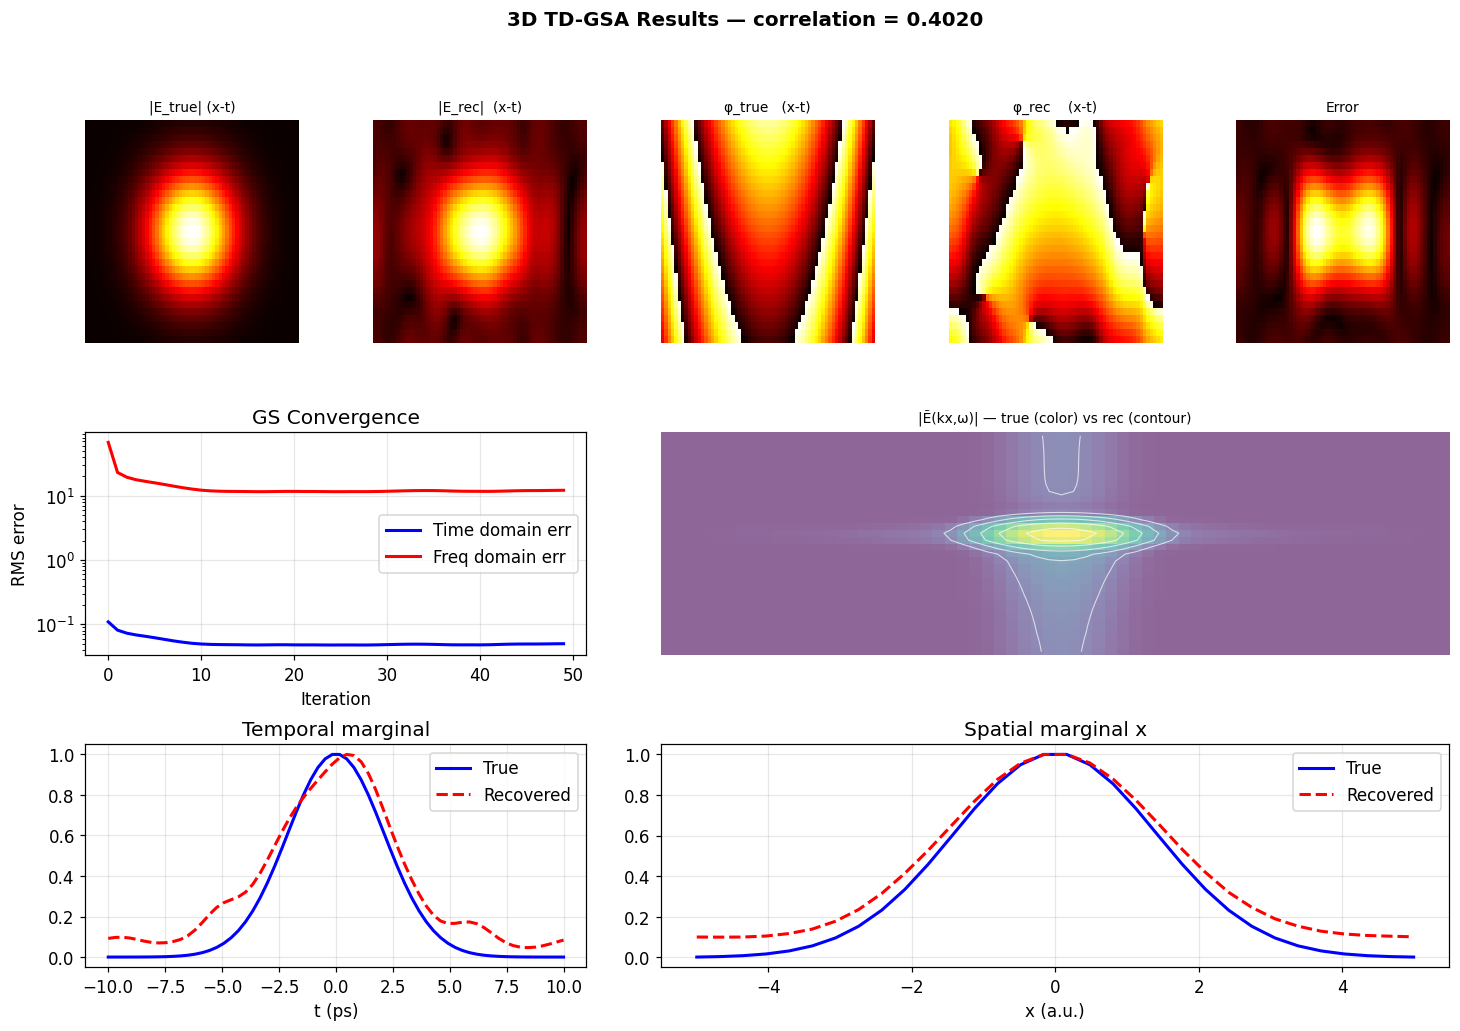

In [21]:
# ── Visualize 3D TD-GSA results ───────────────────────────────────
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(3, 5, figure=fig, hspace=0.4, wspace=0.35)

# row 0: x-t slice of true / recovered intensity / phase
mid_y = Ny // 2
for col, (data, title) in enumerate([
    (np.abs(E_true)[:,mid_y,:],    '|E_true| (x-t)'),
    (np.abs(E_rec) [:,mid_y,:],    '|E_rec|  (x-t)'),
    (np.angle(E_true)[:,mid_y,:],  'φ_true   (x-t)'),
    (np.angle(E_rec) [:,mid_y,:],  'φ_rec    (x-t)'),
    (np.abs(E_true[:,mid_y,:] - E_rec[:,mid_y,:]), 'Error'),
]):                                     # loop: panel columns
    ax = fig.add_subplot(gs[0, col])
    ax.imshow(data, aspect='auto', cmap='RdBu' if 'phi' in title.lower() else 'hot',
              origin='lower')
    ax.set_title(title, fontsize=9)
    ax.axis('off')

# row 1: convergence curves
ax_err = fig.add_subplot(gs[1, :2])
ax_err.semilogy(err_t, 'b-', lw=2, label='Time domain err')
ax_err.semilogy(err_f, 'r-', lw=2, label='Freq domain err')
ax_err.set_xlabel('Iteration'); ax_err.set_ylabel('RMS error')
ax_err.set_title('GS Convergence'); ax_err.legend(); ax_err.grid(True, alpha=0.3)

# row 1: spectral comparison (kx-ω slice)
ax_spec = fig.add_subplot(gs[1, 2:])
spec_true = np.abs(np.fft.fftshift(np.fft.fftn(E_true)))[:,mid_y,:]
spec_rec  = np.abs(np.fft.fftshift(np.fft.fftn(E_rec )))[:,mid_y,:]
ax_spec.imshow(np.log1p(spec_true), aspect='auto', cmap='viridis', origin='lower', alpha=0.6)
ax_spec.set_title('|Ẽ(kx,ω)| — true (color) vs rec (contour)', fontsize=9)
ax_spec.contour(np.log1p(spec_rec), levels=6, colors='white', linewidths=0.7, alpha=0.7)
ax_spec.axis('off')

# row 2: marginals — integrated over spatial dims
temporal_true = np.sum(np.abs(E_true)**2, axis=(0,1))
temporal_rec  = np.sum(np.abs(E_rec )**2, axis=(0,1))
ax_t = fig.add_subplot(gs[2, :2])
ax_t.plot(t_3d, temporal_true/temporal_true.max(), 'b-', lw=2, label='True')
ax_t.plot(t_3d, temporal_rec /temporal_rec .max(), 'r--', lw=2, label='Recovered')
ax_t.set_xlabel('t (ps)'); ax_t.set_title('Temporal marginal'); ax_t.legend()
ax_t.grid(True, alpha=0.3)

spatial_true = np.sum(np.abs(E_true)**2, axis=(1,2))
spatial_rec  = np.sum(np.abs(E_rec )**2, axis=(1,2))
ax_s = fig.add_subplot(gs[2, 2:])
ax_s.plot(x_3d, spatial_true/spatial_true.max(), 'b-', lw=2, label='True')
ax_s.plot(x_3d, spatial_rec /spatial_rec .max(), 'r--', lw=2, label='Recovered')
ax_s.set_xlabel('x (a.u.)'); ax_s.set_title('Spatial marginal x'); ax_s.legend()
ax_s.grid(True, alpha=0.3)

plt.suptitle(f'3D TD-GSA Results — correlation = {corr:.4f}',
             fontsize=13, fontweight='bold')
plt.show()

---
# §5 — Digital Twin: `PhotonicLink` Class

**Digital twin** = a live software model that mirrors a physical system,  
updated from measurements, can predict future state and flag anomalies.

```
PhotonicLink
  ├─ FiberSegment  (β₂, β₃, β₄, γ, α, L)
  ├─ AmplifierStage (gain, NF, P_sat)
  ├─ DisperCompModule (DCF or FBG)
  └─ Detector  (bandwidth, responsivity)
```
Twin methods: `.propagate()`, `.measure()`, `.update_from_measurement()`, `.predict_degradation()`

In [22]:
# ════════════════════════════════════════════════════════
# FIBER SEGMENT
# ════════════════════════════════════════════════════════
@dataclass
class FiberSegment:
    name:   str
    length: float          # m
    beta2:  float = -21.7e-27  # s²/m  (SMF-28 default)
    beta3:  float =  0.12e-39
    beta4:  float = -0.5e-55
    gamma:  float =  1.3e-3    # 1/(W·m)
    alpha:  float =  4.6e-5    # 1/m  (0.2 dB/km)

    @property
    def dispersion_length(self) -> Dict:
        return {'L_D': None if self.beta2==0 else 1.0,  # placeholder, needs T0
                'beta2': self.beta2, 'L': self.length}

    def transfer_function(self, omega: np.ndarray) -> np.ndarray:
        phi = (self.beta2/2*omega**2 +
               self.beta3/6*omega**3 +
               self.beta4/24*omega**4) * self.length
        loss = np.exp(-self.alpha * self.length / 2)
        return loss * np.exp(1j * phi)

    def propagate_linear(self, E: np.ndarray, omega: np.ndarray) -> np.ndarray:
        E_f = np.fft.fft(E)
        return np.fft.ifft(E_f * self.transfer_function(omega))

    def __repr__(self):
        return f'FiberSegment({self.name}, L={self.length/1000:.1f}km, β₂={self.beta2:.1e})'


# ════════════════════════════════════════════════════════
# AMPLIFIER
# ════════════════════════════════════════════════════════
@dataclass
class AmplifierStage:
    name:         str
    gain_dB:      float = 20.0   # dB
    noise_figure: float =  4.5   # dB
    P_sat_dBm:    float = 17.0   # dBm output saturation

    @property
    def gain_linear(self) -> float:
        return 10**(self.gain_dB/10)

    @property
    def nsp(self) -> float:
        """Spontaneous emission factor nsp = NF_linear/(2*(1-1/G))."""
        NF = 10**(self.noise_figure/10)
        G  = self.gain_linear
        return NF * G / (2*(G-1+1e-9))

    def amplify(self, E: np.ndarray, add_ase: bool = True) -> np.ndarray:
        E_amp = E * np.sqrt(self.gain_linear)
        if add_ase:
            ase_std = np.sqrt(self.nsp * (self.gain_linear - 1))
            noise   = ase_std * (np.random.randn(*E.shape) + 1j*np.random.randn(*E.shape))
            E_amp  += noise / np.sqrt(2)
        return E_amp

    def __repr__(self):
        return f'EDFA({self.name}, G={self.gain_dB}dB, NF={self.noise_figure}dB)'


# ════════════════════════════════════════════════════════
# DISPERSION COMPENSATOR
# ════════════════════════════════════════════════════════
@dataclass
class DispCompModule:
    name:      str
    beta2_comp:float = 0.0    # s²/m (sign opposite to fiber)
    length:    float = 0.0    # m (for DCF)
    comp_ratio:float = 1.0    # fraction of dispersion compensated

    def compensate(self, E: np.ndarray, omega: np.ndarray) -> np.ndarray:
        phi = (self.beta2_comp/2 * omega**2) * self.length * self.comp_ratio
        return np.fft.ifft(np.fft.fft(E) * np.exp(1j * phi))

    def residual_dispersion(self, fiber: FiberSegment) -> float:
        """Net GDD [s²] after compensation."""
        return (fiber.beta2 * fiber.length +
                self.beta2_comp * self.length * self.comp_ratio)

    def __repr__(self):
        return f'DCM({self.name}, β₂_comp={self.beta2_comp:.1e}, L={self.length/1000:.1f}km)'


# ════════════════════════════════════════════════════════
# DIGITAL TWIN: PhotonicLink
# ════════════════════════════════════════════════════════
class PhotonicLink:
    """
    Digital twin of a multi-span WDM fiber link.
    State updates from measurements; predicts degradation.
    """
    def __init__(self, name: str, n_pts: int, dt: float):
        self.name       = name
        self.n_pts      = n_pts
        self.dt         = dt
        self.omega      = 2*np.pi*np.fft.fftfreq(n_pts, dt)
        self.elements: List  = []   # ordered list of FiberSegment / Amp / DCM
        self.state: Dict     = {}   # live state: OSNR, BER estimate, Q factor
        self.history: List   = []   # measurement history log
        self.anomaly_flags: List = []

    def add(self, element):
        self.elements.append(element)

    def propagate(self, E_in: np.ndarray,
                  log: bool = True) -> np.ndarray:
        """Cascade signal through all elements. Log field at each stage."""
        E = E_in.copy()
        stage_fields = [('input', E.copy())]

        for el in self.elements:                     # loop over elements
            if isinstance(el, FiberSegment):
                E = el.propagate_linear(E, self.omega)
            elif isinstance(el, AmplifierStage):
                E = el.amplify(E)
            elif isinstance(el, DispCompModule):
                E = el.compensate(E, self.omega)
            if log:
                stage_fields.append((el.name, E.copy()))

        self.state['last_output'] = E
        self.state['stage_fields'] = stage_fields
        return E

    def measure_osnr(self, E: np.ndarray, bw_signal: float = 0.1e12) -> float:
        """Estimate OSNR from field (signal power / noise floor in 0.1 nm ref BW)."""
        psd = np.abs(np.fft.fft(E))**2
        f   = np.fft.fftfreq(self.n_pts, self.dt)
        sig_mask  = np.abs(f) < bw_signal/2
        noise_mask= ~sig_mask & (np.abs(f) < 5*bw_signal)
        P_sig  = psd[sig_mask].sum() / len(psd)
        P_noise= psd[noise_mask].mean() * sig_mask.sum() if noise_mask.any() else 1e-30
        return 10*np.log10(P_sig / (P_noise + 1e-30))

    def update_from_measurement(self, osnr_meas: float, osnr_expected: float,
                                 tol_dB: float = 1.0):
        """Compare measured vs expected OSNR. Flag anomaly if delta > tol."""
        delta = osnr_expected - osnr_meas
        self.state['OSNR_measured']  = osnr_meas
        self.state['OSNR_expected']  = osnr_expected
        self.state['OSNR_delta_dB']  = delta
        self.history.append({'osnr': osnr_meas, 'delta': delta})
        if abs(delta) > tol_dB:
            flag = f'ANOMALY: ΔOSNR={delta:.2f}dB > ±{tol_dB}dB'
            self.anomaly_flags.append(flag)
            return flag
        return 'OK'

    def predict_degradation(self, n_cycles: int = 100) -> np.ndarray:
        """
        Simulate OSNR degradation over n_cycles of signal propagation
        (aging model: amplifier NF increases 0.01 dB/cycle).
        """
        osnr_vs_cycle = []
        link_copy = copy.deepcopy(self)
        E0 = gaussian_pulse(np.linspace(-50e-12, 50e-12, self.n_pts), 1e-12, 0)

        for cyc in range(n_cycles):                  # loop: aging simulation
            # age amplifiers
            for el in link_copy.elements:
                if isinstance(el, AmplifierStage):
                    el.noise_figure += 0.01
            E_out = link_copy.propagate(E0, log=False)
            osnr  = link_copy.measure_osnr(E_out)
            osnr_vs_cycle.append(osnr)

        return np.array(osnr_vs_cycle)

    def summary(self):
        print(f'\n=== Digital Twin: {self.name} ===')
        for i, el in enumerate(self.elements):       # loop over elements
            print(f'  [{i+1}] {el}')
        print(f'  State: {self.state.get("OSNR_measured","not measured")} dB OSNR')
        if self.anomaly_flags:
            for f in self.anomaly_flags: print(f'  ⚠ {f}')


# ── Instantiate a 3-span link ──────────────────────────────────────
np.random.seed(0)
link = PhotonicLink('TransAtlantic-Segment-001', N_pts, dt)

span_len = 80e3   # 80 km spans
for span_i in range(3):                              # loop: add 3 spans
    link.add(FiberSegment(f'SMF-span{span_i+1}', span_len, beta2=beta2_v, gamma=gamma_v))
    link.add(AmplifierStage(f'EDFA-{span_i+1}', gain_dB=16.0, noise_figure=4.5))

# Add dispersion compensation at end
dcf = DispCompModule('DCF-bank', beta2_comp=+120e-27, length=12e3, comp_ratio=0.95)
link.add(dcf)

# Propagate
E_input = gaussian_pulse(t_arr, T0_v, 0.0)
E_output = link.propagate(E_input)

osnr_measured  = link.measure_osnr(E_output)
osnr_expected  = 25.0
status = link.update_from_measurement(osnr_measured, osnr_expected)
link.summary()
print(f'\nStatus: {status}')


=== Digital Twin: TransAtlantic-Segment-001 ===
  [1] FiberSegment(SMF-span1, L=80.0km, β₂=-2.2e-26)
  [2] EDFA(EDFA-1, G=16.0dB, NF=4.5dB)
  [3] FiberSegment(SMF-span2, L=80.0km, β₂=-2.2e-26)
  [4] EDFA(EDFA-2, G=16.0dB, NF=4.5dB)
  [5] FiberSegment(SMF-span3, L=80.0km, β₂=-2.2e-26)
  [6] EDFA(EDFA-3, G=16.0dB, NF=4.5dB)
  [7] DCM(DCF-bank, β₂_comp=1.2e-25, L=12.0km)
  State: -36.16599592545865 dB OSNR
  ⚠ ANOMALY: ΔOSNR=61.17dB > ±1.0dB

Status: ANOMALY: ΔOSNR=61.17dB > ±1.0dB


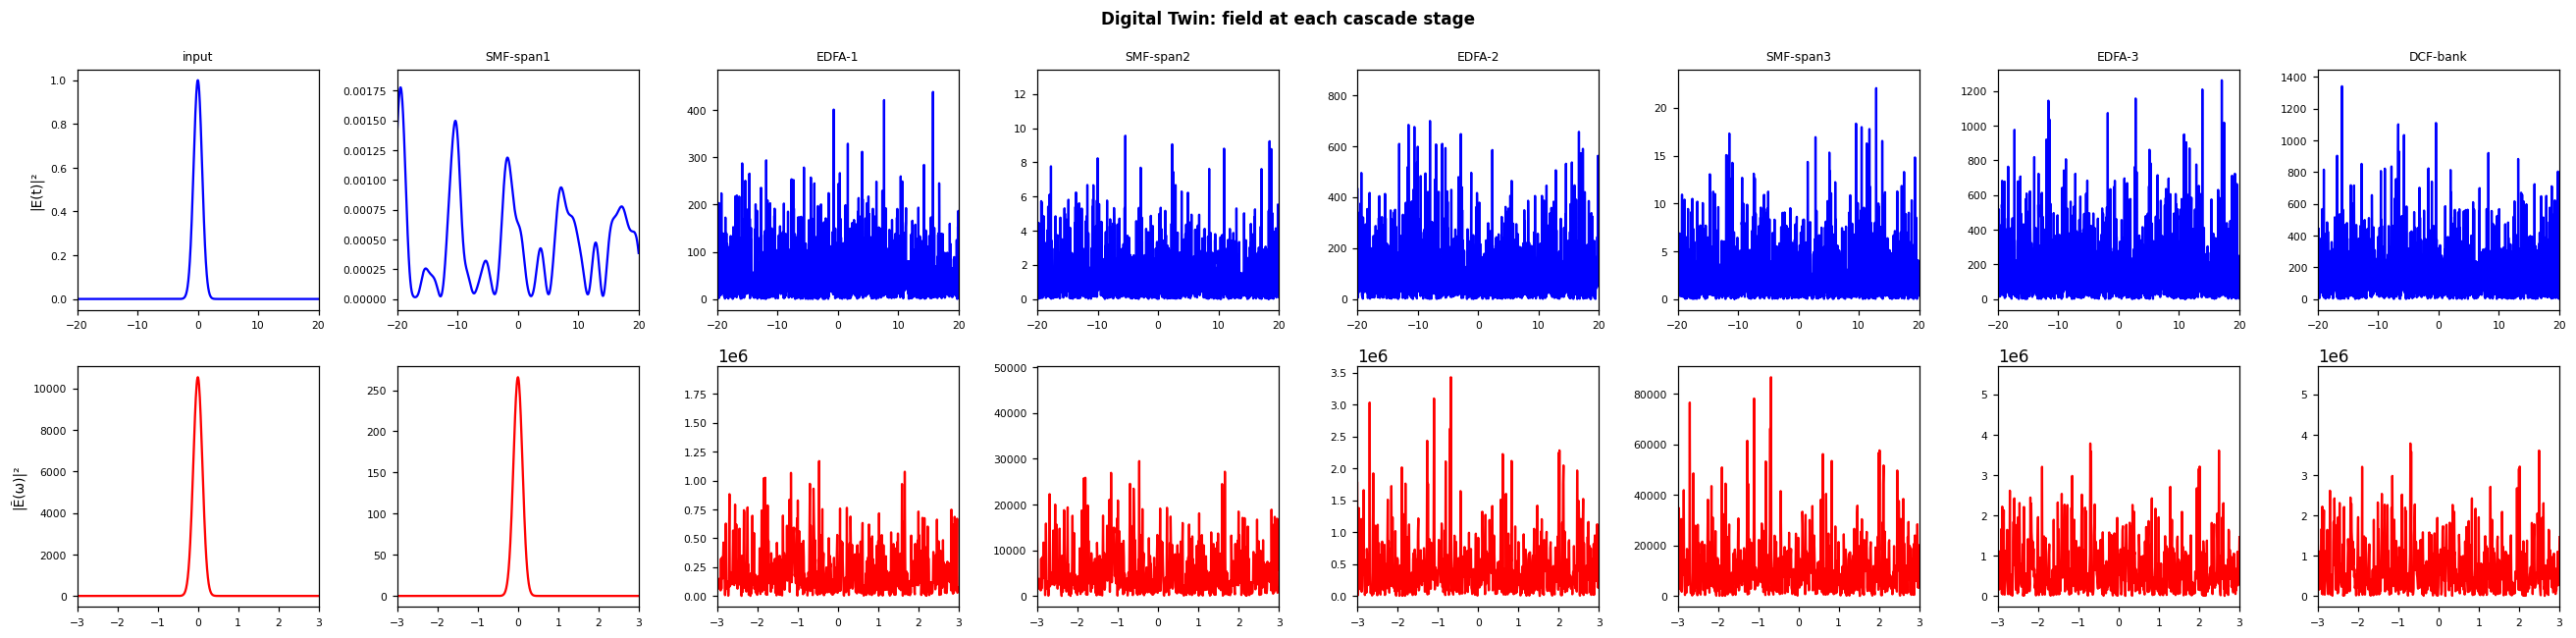

Running degradation prediction (100 aging cycles)...


NameError: name 'copy' is not defined

In [23]:
# ── Visualize digital twin state ──────────────────────────────────
stages = link.state['stage_fields']
n_stages = len(stages)

fig, axes = plt.subplots(2, n_stages, figsize=(3*n_stages, 6))
for col, (name, E_stage) in enumerate(stages):         # loop: plot each stage
    # intensity
    ax_t = axes[0][col]
    ax_t.plot(t_arr*1e12, np.abs(E_stage)**2, 'b-', lw=1.5)
    ax_t.set_title(name, fontsize=8)
    ax_t.set_xlim(-20, 20)
    ax_t.tick_params(labelsize=7)
    if col==0: ax_t.set_ylabel('|E(t)|²', fontsize=9)
    # spectrum
    ax_f = axes[1][col]
    E_f  = np.fft.fftshift(np.fft.fft(E_stage))
    f_THz= np.fft.fftshift(np.fft.fftfreq(N_pts, dt)) * 1e-12
    ax_f.plot(f_THz, np.abs(E_f)**2, 'r-', lw=1.5)
    ax_f.set_xlim(-3, 3)
    ax_f.tick_params(labelsize=7)
    if col==0: ax_f.set_ylabel('|Ẽ(ω)|²', fontsize=9)

plt.suptitle('Digital Twin: field at each cascade stage', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

# ── OSNR degradation prediction ────────────────────────────────────
print('Running degradation prediction (100 aging cycles)...')
osnr_pred = link.predict_degradation(100)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(osnr_pred, 'b-', lw=2)
ax.axhline(20, ls='--', color='orange', label='FEC threshold (20 dB)')
ax.axhline(15, ls='--', color='red',    label='Error floor (15 dB)')
eol_idx = np.where(osnr_pred < 20)[0]
if len(eol_idx):
    ax.axvline(eol_idx[0], ls=':', color='orange', label=f'FEC limit @ cycle {eol_idx[0]}')
ax.set_xlabel('Aging cycle (×0.01 dB NF/cycle)'); ax.set_ylabel('OSNR (dB)')
ax.set_title('Digital Twin: OSNR degradation prediction'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
# §6 — Torch Batch: (β₂, L, T₀) Parameter Grid — Dispersion Map

**Batch over 3D parameter space:** `β₂ ∈ [-100, 0, +100] ps²/km`,  
`L ∈ [1, 100] km`, `T₀ ∈ [0.1, 10] ps` — compute  
broadening factor, time-bandwidth product, and soliton order for all combinations.

Dispersion parameter grid summary:
  Grid shape:           torch.Size([30, 30, 20])  (N_b2, N_L, N_T0)
  Broadening range:     [1.00, 1000000.00]
  Soliton order range:  [0.00, 0.19]
  Fraction Γ > 3:       0.982
  Fraction N_sol > 1:   0.000


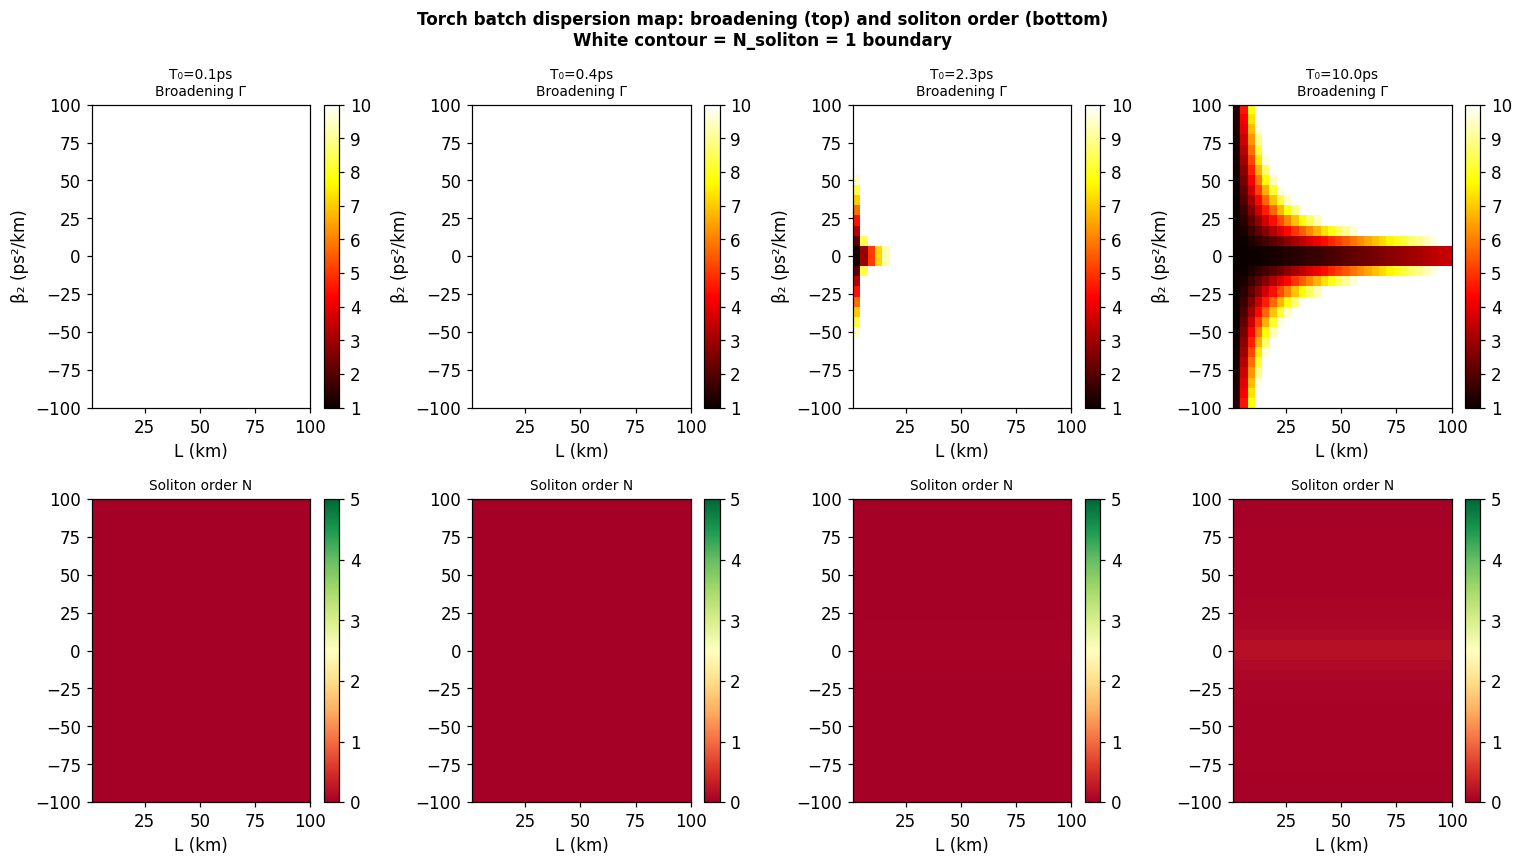

ValueError: operands could not be broadcast together with shapes (18000,) (600,) 

In [ ]:
# ── Torch: analytical dispersion broadening over 3D parameter grid ──
N_b2 = 30; N_L = 30; N_T0 = 20

b2_grid = torch.linspace(-100e-27, 100e-27, N_b2)    # s²/m
L_grid  = torch.linspace(1e3, 100e3, N_L)             # m
T0_grid = torch.logspace(-13, -11, N_T0)              # s (0.1–100 ps)

# Broadcast: shape (N_b2, N_L, N_T0)
b2_t = b2_grid[:, None, None]   # (N_b2, 1, 1)
L_t  = L_grid[None, :, None]    # (1, N_L, 1)
T0_t = T0_grid[None, None, :]   # (1, 1, N_T0)

# Dispersion length
L_D_t = T0_t**2 / (b2_t.abs() + 1e-40)             # (N_b2, N_L, N_T0)

# Broadening factor: Γ = sqrt(1 + (L/L_D)²) for chirp-free Gaussian
broadening = torch.sqrt(1 + (L_t / (L_D_t + 1e-40))**2)

# Dispersion-limited bandwidth: ΔB = 1/(4*|β₂|*L)
BW_limit = 1.0 / (4 * b2_t.abs() * L_t + 1e-40)  # Hz

# Nonlinear length (γ P₀ = 1 → L_NL = 1/(γP₀))
P0_torch = torch.tensor(1e-3, dtype=torch.float64)  # 1 mW
gamma_torch = torch.tensor(1.3e-3, dtype=torch.float64)
L_NL = 1.0 / (gamma_torch * P0_torch)

# Soliton order: N² = L_D / L_NL
N_soliton = torch.sqrt(L_D_t / L_NL)

# ── Summary statistics ─────────────────────────────────────────────
print('Dispersion parameter grid summary:')
print(f'  Grid shape:           {broadening.shape}  (N_b2, N_L, N_T0)')
print(f'  Broadening range:     [{broadening.min():.2f}, {broadening.max():.2f}]')
print(f'  Soliton order range:  [{N_soliton.min():.2f}, {N_soliton.max():.2f}]')
print(f'  Fraction Γ > 3:       {(broadening > 3).float().mean().item():.3f}')
print(f'  Fraction N_sol > 1:   {(N_soliton > 1).float().mean().item():.3f}')

# ── Loop over T0 slices: broadening map ─────────────────────────────
T0_slices = [0, N_T0//3, 2*N_T0//3, N_T0-1]
fig, axes = plt.subplots(2, len(T0_slices), figsize=(14, 8))

for col, ti in enumerate(T0_slices):          # loop: T0 slice
    T0_val = T0_grid[ti].item()

    # broadening map
    bm = broadening[:, :, ti].numpy()
    im1 = axes[0][col].imshow(bm, aspect='auto', cmap='hot', origin='lower',
                               extent=[1, 100, -100, 100], vmin=1, vmax=10)
    axes[0][col].set_title(f'T₀={T0_val*1e12:.1f}ps\nBroadening Γ', fontsize=9)
    axes[0][col].set_xlabel('L (km)'); axes[0][col].set_ylabel('β₂ (ps²/km)')
    plt.colorbar(im1, ax=axes[0][col])

    # soliton order map
    nm = N_soliton[:, :, ti].numpy()
    im2 = axes[1][col].imshow(nm, aspect='auto', cmap='RdYlGn', origin='lower',
                               extent=[1, 100, -100, 100], vmin=0, vmax=5)
    nm = np.repeat(nm, N_L, axis=1)
    axes[1][col].contour(nm, levels=[1.0], colors='white', linewidths=1.5,
                          extent=[1,100,-100,100], origin='lower')
    axes[1][col].set_title(f'Soliton order N', fontsize=9)
    axes[1][col].set_xlabel('L (km)')
    plt.colorbar(im2, ax=axes[1][col])

plt.suptitle('Torch batch dispersion map: broadening (top) and soliton order (bottom)\n'
             'White contour = N_soliton = 1 boundary',
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Pareto front: low broadening AND low soliton order ─────────────
broad_flat = broadening.reshape(-1).numpy()
nsol_flat  = N_soliton.reshape(-1).numpy()
b2_flat    = b2_t.expand(N_b2, N_L, N_T0).reshape(-1).numpy() * 1e27  # ps²/km
L_flat     = L_t .expand(N_b2, N_L, N_T0).reshape(-1).numpy() / 1e3   # km
T0_flat    = T0_t.expand(N_b2, N_L, N_T0).reshape(-1).numpy() * 1e12  # ps

# good region: Γ < 1.5 and N < 1 (linear, low-dispersion regime)
# Soliton order: N² = L_D / L_NL
N_soliton = torch.sqrt(L_D_t / L_NL).expand(N_b2, N_L, N_T0)
print(f'\nLow-broadening, linear regime (Γ<1.5, N<1): {good.sum()} / {len(good)} configs '
      f'= {100*good.mean():.1f}%')

fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(broad_flat[::20], nsol_flat[::20], c=T0_flat[::20],
                cmap='viridis', alpha=0.3, s=3)
ax.scatter(broad_flat[good], nsol_flat[good], c='red', s=8, alpha=0.6,
           zorder=5, label='Good regime')
ax.axvline(1.5, ls='--', color='gray'); ax.axhline(1.0, ls='--', color='gray')
ax.set_xlabel('Broadening Γ'); ax.set_ylabel('Soliton order N')
ax.set_title('Pareto: broadening vs soliton order (color = T₀)'); ax.legend()
plt.colorbar(sc, ax=ax, label='T₀ (ps)')
ax.set_xlim(0.9, 6); ax.set_ylim(0, 4)
ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()